In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Unzip the archive to access the CSV file
# The -o flag overwrites existing files without prompting.
# The -d /content/ flag specifies the destination directory for extraction.
!unzip -o '/content/archive (3).zip' -d '/content/'

df = pd.read_csv('/content/flipkart_com-ecommerce_sample.csv')
df.head()
df.info()

Archive:  /content/archive (3).zip
  inflating: /content/flipkart_com-ecommerce_sample.csv  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   uniq_id                  20000 non-null  object 
 1   crawl_timestamp          20000 non-null  object 
 2   product_url              20000 non-null  object 
 3   product_name             20000 non-null  object 
 4   product_category_tree    20000 non-null  object 
 5   pid                      20000 non-null  object 
 6   retail_price             19922 non-null  float64
 7   discounted_price         19922 non-null  float64
 8   image                    19997 non-null  object 
 9   is_FK_Advantage_product  20000 non-null  bool   
 10  description              19998 non-null  object 
 11  product_rating           20000 non-null  object 
 12  overall_rating           20000 non-nu

In [3]:
# check key columns you'll likely need
print(df.columns.tolist())

# typical columns: product_name, retail_price, discounted_price,
# product_category_tree, product_rating, overall_rating

# drop rows with missing price or rating
df_clean = df.dropna(subset=['retail_price', 'discounted_price'])

# extract top-level category from product_category_tree (it's usually nested)
df_clean['main_category'] = df_clean['product_category_tree'].str.split('>>').str[0].str.strip('["')


['uniq_id', 'crawl_timestamp', 'product_url', 'product_name', 'product_category_tree', 'pid', 'retail_price', 'discounted_price', 'image', 'is_FK_Advantage_product', 'description', 'product_rating', 'overall_rating', 'brand', 'product_specifications']


/tmp/ipykernel_2431/259469467.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['main_category'] = df_clean['product_category_tree'].str.split('>>').str[0].str.strip('["')


In [4]:
# common column names in this dataset - verify against your df.columns.tolist()
# rename for consistency if needed
df_clean = df_clean.rename(columns={
    'product_rating': 'rating',
    'brand': 'brand',
    'retail_price': 'mrp',
    'discounted_price': 'selling_price'
})

# convert rating to numeric (often has 'No rating available' as string)
df_clean['rating'] = pd.to_numeric(df_clean['rating'], errors='coerce')

# calculate discount %
df_clean['discount_pct'] = ((df_clean['mrp'] - df_clean['selling_price']) / df_clean['mrp']) * 100

# drop rows with no rating for this analysis
rated = df_clean.dropna(subset=['rating'])

In [5]:

# normalize price (0-1 scale) so it's comparable across categories
rated['price_normalized'] = (rated['selling_price'] - rated['selling_price'].min()) / \
                             (rated['selling_price'].max() - rated['selling_price'].min())

# value score = rating relative to price (higher = better deal)
rated['value_score'] = rated['rating'] / (rated['price_normalized'] + 0.01) # +0.01 avoids divide by zero

# top value products (high rating, low relative price)
top_value = rated.sort_values('value_score', ascending=False).head(20)
print(top_value[['product_name', 'rating', 'selling_price', 'value_score']])

# worst value (overpriced relative to rating)
worst_value = rated.sort_values('value_score', ascending=True).head(20)
print(worst_value[['product_name', 'rating', 'selling_price', 'value_score']])

                                            product_name  rating  \
14979  Casotec Super Clear Screen Protector Screen Gu...     5.0   
2167           Vaishna Fashion Women's Full Coverage Bra     5.0   
6811                 Zeva Keepz U On Gift Set  Combo Set     5.0   
2886           Vaishna Fashion Women's Full Coverage Bra     5.0   
2723                Magiq Nice Merry Women's Push-up Bra     5.0   
2433           S4S Comfortable Women's Full Coverage Bra     5.0   
2541             Q-rious Dzire Women's Full Coverage Bra     5.0   
2648             Q-rious Dzire Women's Full Coverage Bra     5.0   
16276     DreamShop Flex Flexible Portable USB Led Light     5.0   
2157       Grafion Comfortable Women's Full Coverage Bra     5.0   
6690     Outshiny Eagle Printed Art Polyester Pencil Box     5.0   
10481                                   Metmo Flip Flops     5.0   
10633                                        Max T-Shirt     5.0   
8630    Agricart African Marigold Vanilla F1- Wh

/tmp/ipykernel_2431/1447640092.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rated['price_normalized'] = (rated['selling_price'] - rated['selling_price'].min()) / \
/tmp/ipykernel_2431/1447640092.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rated['value_score'] = rated['rating'] / (rated['price_normalized'] + 0.01) # +0.01 avoids divide by zero


In [6]:
category_brand = rated.groupby(['main_category', 'brand']).agg(
    avg_rating=('rating', 'mean'),
    avg_price=('selling_price', 'mean'),
    avg_discount=('discount_pct', 'mean'),
    product_count=('product_name', 'count')
).reset_index()

# filter for brands with enough products to be meaningful
category_brand = category_brand[category_brand['product_count'] >= 5]

# flag overpriced brands: high price, low rating relative to category average
category_avg = rated.groupby('main_category')['rating'].transform('mean')
rated['rating_vs_category_avg'] = rated['rating'] - category_avg

overpriced = category_brand.sort_values('avg_price', ascending=False).head(15)
print(overpriced)


              main_category           brand  avg_rating    avg_price  \
112              Computers             Asus    3.973684  6753.842105   
114              Computers           Belkin    3.637500  5355.250000   
141              Computers          Netgear    4.137500  5204.875000   
149              Computers          TP-LINK    3.910526  2505.263158   
152              Computers            Tenda    4.184211  1940.105263   
121              Computers           D-Link    4.033333  1798.000000   
278              Jewellery   Pearl Paradise    4.285714  1654.142857   
160              Computers            iBall    3.500000  1470.333333   
362  Mobiles & Accessories             Rock    3.400000  1403.000000   
237        Home Furnishing          Trident    3.214286   896.714286   
34   Cameras & Accessories              JJC    3.570000   803.900000   
392       Tools & Hardware            Bosch    4.950000   744.300000   
391       Tools & Hardware          Blessed    3.216667   650.83

/tmp/ipykernel_2431/2789282597.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rated['rating_vs_category_avg'] = rated['rating'] - category_avg


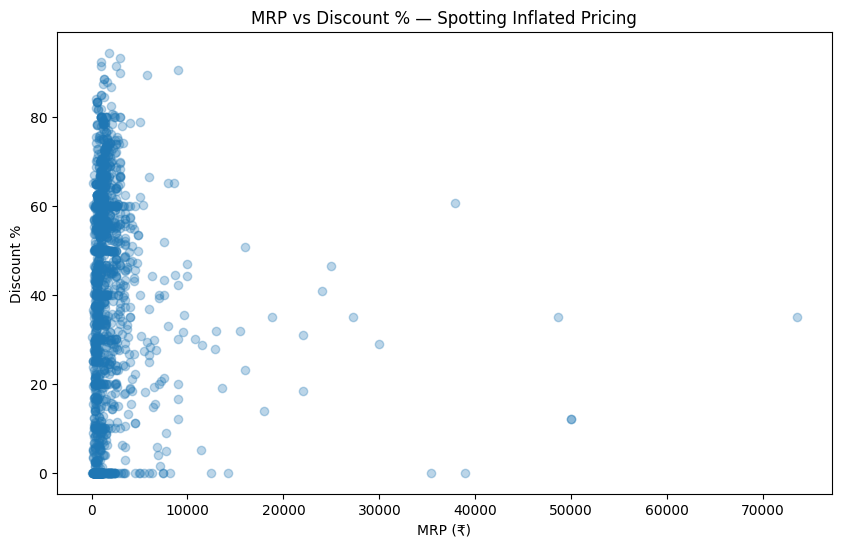

Correlation between MRP and Discount%: -0.01


In [7]:
# do higher-priced items get suspiciously deeper discounts?
plt.figure(figsize=(10,6))
plt.scatter(rated['mrp'], rated['discount_pct'], alpha=0.3)
plt.xlabel('MRP (₹)')
plt.ylabel('Discount %')
plt.title('MRP vs Discount % — Spotting Inflated Pricing')
plt.show()

correlation = rated['mrp'].corr(rated['discount_pct'])
print(f"Correlation between MRP and Discount%: {correlation:.2f}")



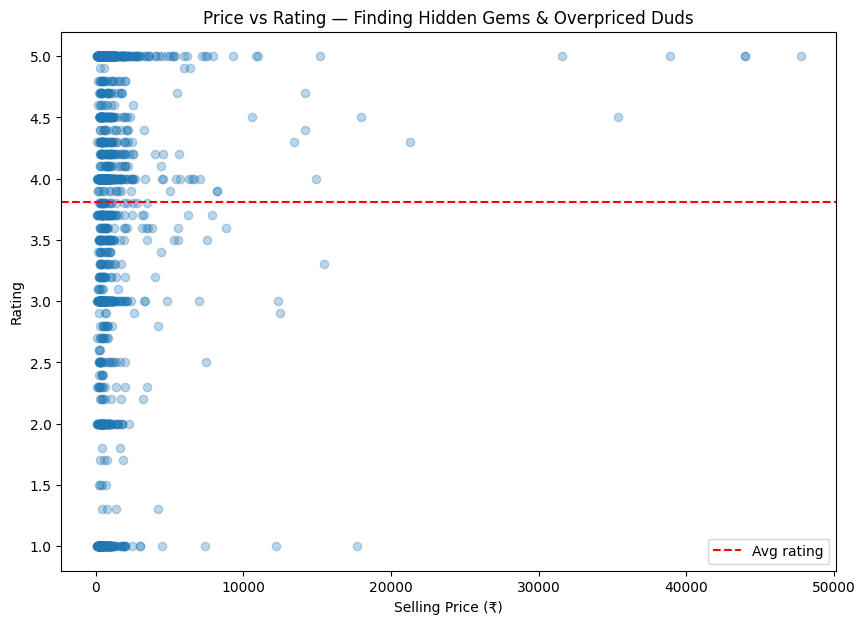

In [8]:
plt.figure(figsize=(10,7))
plt.scatter(rated['selling_price'], rated['rating'], alpha=0.3)
plt.xlabel('Selling Price (₹)')
plt.ylabel('Rating')
plt.title('Price vs Rating — Finding Hidden Gems & Overpriced Duds')
plt.axhline(rated['rating'].mean(), color='r', linestyle='--', label='Avg rating')
plt.legend()
plt.show()